# Garbage Classification: Custom CNN vs. Transfer Learning

A computer vision project comparing two approaches to classifying images of garbage into 10 categories: **battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes, and trash**.

## Project Overview

This notebook implements and compares two convolutional neural network approaches for waste classification:

1. **Custom CNN trained from scratch** — A 5-block convolutional architecture with BatchNorm, Global Average Pooling, and a small classifier head (~3.9M parameters). Trained end-to-end on the garbage dataset with class-weighted cross-entropy loss, data augmentation, and a learning rate scheduler.

2. **Transfer learning with pretrained ResNet50** — A 50-layer residual network pretrained on ImageNet, with the final classifier replaced for our 10-class task (~23.5M parameters). Trained with a two-stage strategy: a feature-extraction warm-up (frozen backbone, classifier head only) followed by full fine-tuning with a reduced learning rate.

## Results

| Model | Validation Accuracy | Parameters |
|-------|---------------------|------------|
| Custom CNN (from scratch) | **87.65%** | 3.9M |
| Pretrained ResNet50 | **97.67%** | 23.5M |

Transfer learning provided the largest gains on the most challenging classes:

- **plastic**: +17.3% (77.8% → 95.1%)
- **glass**: +15.6% (82.3% → 97.9%)
- **battery**: +14.1% (84.9% → 98.9%)
- **trash**: +13.9% (81.8% → 95.7%)

Beyond raw accuracy, ResNet50 also produced significantly better-calibrated confidence, classifying ambiguous samples at 99-100% confidence where the custom CNN often hovered at 70-80%.

## Techniques Demonstrated

- **Data preprocessing**: ImageNet normalization, train/validation augmentation separation, fixed-seed splits for reproducibility
- **Data augmentation**: RandomResizedCrop, horizontal flips, rotation, color jitter
- **Custom architecture design**: Convolutional blocks with BatchNorm, Global Average Pooling, dropout regularization
- **Transfer learning**: Two-stage training (feature extraction → fine-tuning) with differentiated learning rates
- **Class imbalance handling**: Balanced class weights computed from training distribution
- **Training engineering**: Best-model checkpointing by validation accuracy, ReduceLROnPlateau scheduler, weight decay, early-stopping signals
- **Model evaluation**: Per-class precision/recall/F1, confusion matrix analysis (raw and normalized)
- **Model comparison**: Side-by-side metric tables, per-class accuracy bar charts, and sample prediction visualizations with confidence scores

## Tech Stack

- **PyTorch** + **torchvision** for model definition, training, and pretrained weights
- **scikit-learn** for class weighting and classification metrics
- **matplotlib** for visualizations
- **Google Colab** (GPU runtime) for training

## Dataset

10-class garbage image dataset (~19,762 images total), split 80/20 into training and validation sets.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/CNNProject/garbage_dataset_v2.zip" /content/
!unzip -q /content/garbage_dataset_v2.zip -d /content/
!ls /content/garbage_dataset_v2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/garbage_dataset_v2/battery/battery_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
battery     cardboard  glass  paper    shoes
biological  clothes    metal  plastic  trash


## 1. Setup: Imports, Reproducibility, and GPU Check

This cell handles project setup:

- **Imports** — all libraries needed throughout the notebook (PyTorch, torchvision, scikit-learn, matplotlib).
- **Random seeds** — fixed across PyTorch, NumPy, and Python's random module so that training is reproducible. Anyone re-running this notebook should get the same results.
- **Device setup** — checks for a CUDA-enabled GPU and falls back to CPU if unavailable. Training a CNN on CPU is impractically slow, so a GPU is essential. This notebook was trained on Google Colab (Pro tier).

In [2]:
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
import copy
import random

# Reproducibility — fix random seeds so results are repeatable
SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
else:
    print("Training will use CPU.")

CUDA available: True
GPU Device Name: NVIDIA A100-SXM4-40GB


## 2. Dataset Loading and Preprocessing

The dataset is organized into 10 subfolders (one per class) and loaded using `torchvision.datasets.ImageFolder`, which automatically infers labels from the folder structure.

### Transform Pipelines

Two separate transform pipelines are defined — one for training and one for validation:

**Training pipeline** applies data augmentation to artificially expand the dataset and reduce overfitting:
- `Resize(256)` followed by `RandomResizedCrop(224, scale=(0.8, 1.0))` — randomly crops 80–100% of the image and resizes to 224×224, exposing the model to varied framing and zoom levels.
- `RandomHorizontalFlip` — mirrors images horizontally with 50% probability.
- `RandomRotation(15)` — rotates by up to ±15 degrees to simulate different camera angles.
- `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)` — perturbs color properties to make the model robust to varying lighting conditions.

**Validation pipeline** uses only deterministic resizing — no augmentation. This is essential: validation must measure performance on unaltered images to produce a fair, reproducible accuracy metric.

Both pipelines end with `ToTensor()` to convert PIL images to PyTorch tensors with pixel values in [0, 1], followed by `Normalize` using ImageNet's per-channel mean and standard deviation. This normalization is required for compatibility with pretrained models (which expect inputs in this distribution) and helps custom networks converge faster and more stably.

### Train/Validation Split

Because training and validation require different transform pipelines, the dataset is loaded twice — once with each transform — and indices are then split into train and validation subsets. A fixed random seed ensures the same images consistently fall into the same split across runs, making results reproducible and enabling fair comparison between models.

The split ratio is 80% train / 20% validation.

### Input Resolution

Images are resized to 224×224. This is the standard input resolution for most ImageNet-pretrained models (including ResNet50 used later in this notebook) and preserves significantly more detail than smaller resolutions like 128×128.

### DataLoaders

Both DataLoaders use a batch size of 32 with `num_workers=2` for parallel data loading and `pin_memory=True` to accelerate CPU→GPU transfers. Only the training loader shuffles its data each epoch; the validation loader maintains fixed order to keep metrics directly comparable across epochs.


In [3]:
# Define separate transforms for training (with augmentation) and validation (no augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load dataset twice with different transforms (same underlying images)
DATA_DIR = "/content/garbage_dataset_v2"
train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_dataset_full = datasets.ImageFolder(DATA_DIR, transform=val_transform)

# Class names (consistent across both)
classes = train_dataset_full.classes
num_classes = len(classes)
print(f"Found {len(train_dataset_full)} images across {num_classes} classes:")
print(classes)

# Create train/val split with a fixed seed for reproducibility
num_samples = len(train_dataset_full)
generator = torch.Generator().manual_seed(SEED)
shuffled_indices = torch.randperm(num_samples, generator=generator).tolist()

train_size = int(0.8 * num_samples)
train_indices = shuffled_indices[:train_size]
val_indices = shuffled_indices[train_size:]

# Wrap subsets so the correct transform is applied to each
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(val_dataset_full, val_indices)

print(f"\nTrain set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Found 19762 images across 10 classes:
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

Train set size: 15809
Validation set size: 3953


## 3. Custom CNN Architecture

This section defines a convolutional neural network built from scratch for garbage classification. The architecture follows a standard pattern: progressively deepening feature maps through repeated convolutional blocks, followed by global pooling and a linear classifier.

### Architecture Overview

| Stage | Operation | Output Shape |
|-------|-----------|--------------|
| Input | - | 3 × 224 × 224 |
| Block 1 | Conv(3→64) → BN → ReLU → MaxPool | 64 × 112 × 112 |
| Block 2 | Conv(64→128) → BN → ReLU → MaxPool | 128 × 56 × 56 |
| Block 3 | Conv(128→256) → BN → ReLU → MaxPool | 256 × 28 × 28 |
| Block 4 | Conv(256→512) → BN → ReLU → MaxPool | 512 × 14 × 14 |
| Block 5 | Conv(512→512) → BN → ReLU → MaxPool | 512 × 7 × 7 |
| Pooling | Global Average Pooling | 512 |
| Classifier | Dropout(0.4) → Linear(512→10) | 10 |

### Design Decisions

**Batch Normalization** is applied after every convolution. BatchNorm normalizes activations across each mini-batch, which stabilizes training, allows higher learning rates, and acts as a mild regularizer. This is one of the most impactful additions for training deep networks effectively.

**Progressive channel doubling** (64 → 128 → 256 → 512) is a well-established design pattern (used in VGG, ResNet, and most modern CNNs). Early layers detect simple features like edges and require fewer channels; deeper layers learn more abstract, class-specific patterns and benefit from greater representational capacity.

**Global Average Pooling (GAP)** replaces the traditional flatten-then-large-FC approach. After the convolutional stack produces a 512×7×7 feature map, GAP averages each channel's 7×7 spatial map into a single value, yielding a 512-dimensional feature vector. This has several advantages over flattening:
- Drastically fewer parameters (eliminating a potentially massive fully-connected layer)
- Built-in spatial invariance — the model doesn't depend on object position within the frame
- Reduced overfitting risk

**Dropout(0.4)** is applied before the final classifier as additional regularization, randomly zeroing 40% of features during training to prevent over-reliance on any specific neuron.

**ReLU activations** with `inplace=True` are used throughout to reduce memory consumption during forward passes.


In [4]:
class GarbageCNN(nn.Module):
    """
    Custom CNN for 10-class garbage image classification.

    Architecture:
        Input (3, 224, 224)
            -> 5 convolutional blocks (Conv -> BatchNorm -> ReLU -> MaxPool)
            -> Global Average Pooling
            -> Dropout + Linear classifier
    """

    def __init__(self, num_classes=10):
        super(GarbageCNN, self).__init__()

        self.features = nn.Sequential(
            self._make_block(3, 64),       # 224 -> 112
            self._make_block(64, 128),     # 112 -> 56
            self._make_block(128, 256),    # 56  -> 28
            self._make_block(256, 512),    # 28  -> 14
            self._make_block(512, 512),    # 14  -> 7
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    @staticmethod
    def _make_block(in_channels, out_channels):
        """Single convolutional block: Conv -> BN -> ReLU -> MaxPool."""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Instantiate the model and move it to the GPU
custom_cnn = GarbageCNN(num_classes=num_classes).to(device)

# Print parameter count
total_params = sum(p.numel() for p in custom_cnn.parameters())
trainable_params = sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     3,918,858
Trainable parameters: 3,918,858


## 3.1. Optional: Load Pretrained Weights (Skip Training)

If you have previously trained this model and saved the weights, you can load them here to skip training and proceed directly to evaluation. To use this path, set `WEIGHTS_DIR` below to the folder containing `custom_cnn_best.pth` and `custom_cnn_history.json`.

If you want to train from scratch instead, skip this cell and run the next training cell.

In [ ]:
import json

# Path to the folder containing the saved weights and history files.
# Update this path to match your environment.
WEIGHTS_DIR = "/content/drive/MyDrive/CNNProject"

# Load custom CNN weights
custom_cnn.load_state_dict(torch.load(f"{WEIGHTS_DIR}/custom_cnn_best.pth"))
custom_cnn.eval()

# Load training history
with open(f"{WEIGHTS_DIR}/custom_cnn_history.json") as f:
    history = json.load(f)

print(f"Custom CNN weights loaded from {WEIGHTS_DIR}/custom_cnn_best.pth")
print(f"Best validation accuracy from saved history: {max(history['val_acc']):.2f}%")

## 4. Training the Custom CNN

This section trains the custom CNN using a structured loop that tracks both training and validation metrics each epoch, adapts the learning rate based on validation performance, and preserves the best-performing weights.

### Loss Function with Class Weights

The garbage dataset contains uneven numbers of images per class. Without correction, the model would bias predictions toward more frequent classes. To counteract this, per-class weights are computed using `sklearn.utils.class_weight.compute_class_weight` with the `'balanced'` strategy, which assigns higher weights to underrepresented classes. These weights are passed to `nn.CrossEntropyLoss`, ensuring each class contributes proportionally to the total loss regardless of its frequency.

The weighted cross-entropy loss is:

$$
\mathcal{L} = -\sum_{i=1}^{C} w_i \cdot y_i \cdot \log(\hat{y}_i)
$$

where $C$ is the number of classes, $y_i$ is the one-hot true label, $\hat{y}_i$ is the predicted probability, and $w_i$ is the class weight.

### Optimizer

**Adam** is used with a learning rate of $10^{-3}$ and weight decay of $10^{-4}$. Adam adapts per-parameter learning rates using gradient moment estimates, making it robust to hyperparameter choices. The weight decay term applies L2 regularization to all parameters, discouraging large weights and helping prevent overfitting.

### Learning Rate Scheduler

`ReduceLROnPlateau` monitors validation loss and reduces the learning rate by 50% when no improvement is observed for 3 consecutive epochs. This allows the model to make large updates early in training when far from the optimum, then take progressively finer steps as it converges — typically yielding a meaningful accuracy boost compared to a fixed learning rate.

### Training Loop

Each epoch consists of:

1. **Training phase** — model in train mode (BatchNorm and Dropout active). For each batch: forward pass, weighted loss computation, backward pass, optimizer step. Loss and accuracy are accumulated.
2. **Validation phase** — model in eval mode (BatchNorm uses running statistics, Dropout disabled). Gradients are disabled with `torch.no_grad()` for efficiency. The model is scored on the validation set without affecting weights.
3. **Scheduler step** — the learning rate is potentially reduced based on validation loss.
4. **Best-model tracking** — if validation accuracy improves, the current weights are saved to memory.

### Best-Model Selection

Rather than keeping the final epoch's weights (which may not be the best), the weights corresponding to the highest validation accuracy observed during training are restored at the end. This standard practice ensures the deployed model is the strongest version seen during the run.

The best weights are also persisted to Google Drive for later loading and inference.


In [5]:
import time
import os

# ============================================================
# Compute class weights to handle class imbalance
# ============================================================
train_targets = [train_dataset_full.targets[i] for i in train_indices]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_targets),
    y=train_targets,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Per-class weights:")
for cls, w in zip(classes, class_weights):
    print(f"  {cls:<12} {w:.3f}")

# ============================================================
# Loss, optimizer, and learning rate scheduler
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(custom_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# ============================================================
# Training loop
# ============================================================
NUM_EPOCHS = 40
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_weights = copy.deepcopy(custom_cnn.state_dict())

print(f"\n{'Epoch':>5} | {'TrainLoss':>10} {'TrainAcc':>9} | {'ValLoss':>10} {'ValAcc':>9} | {'LR':>10} | {'Time':>6}")
print("-" * 80)

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- Training phase ---
    custom_cnn.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = custom_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = 100.0 * running_correct / running_total

    # --- Validation phase ---
    custom_cnn.eval()
    running_loss, running_correct, running_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = custom_cnn(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

    val_loss = running_loss / running_total
    val_acc = 100.0 * running_correct / running_total

    # Record metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save best model weights based on validation accuracy
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(custom_cnn.state_dict())

    epoch_time = time.time() - start_time
    marker = "  *" if is_best else ""
    print(f"{epoch+1:>5} | {train_loss:>10.4f} {train_acc:>8.2f}% | "
          f"{val_loss:>10.4f} {val_acc:>8.2f}% | {current_lr:>10.6f} | "
          f"{epoch_time:>5.1f}s{marker}")

# ============================================================
# Restore best weights and persist them
# ============================================================
custom_cnn.load_state_dict(best_model_weights)
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

# Save best weights to Google Drive
SAVE_DIR = "/content/drive/MyDrive/CNNProject"
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(best_model_weights, os.path.join(SAVE_DIR, "custom_cnn_best.pth"))
print(f"Best model saved to: {SAVE_DIR}/custom_cnn_best.pth")

# Save training history for later plotting
import json
with open(os.path.join(SAVE_DIR, "custom_cnn_history.json"), "w") as f:
    json.dump(history, f)

Per-class weights:
  battery      2.083
  biological   1.986
  cardboard    1.096
  clothes      0.370
  glass        0.647
  metal        1.914
  paper        1.176
  plastic      1.001
  shoes        0.997
  trash        2.080

Epoch |  TrainLoss  TrainAcc |    ValLoss    ValAcc |         LR |   Time
--------------------------------------------------------------------------------
    1 |     1.8985    33.90% |     1.8531    38.65% |   0.001000 |  82.7s  *
    2 |     1.7152    39.96% |     1.6240    39.69% |   0.001000 |  82.8s  *
    3 |     1.6105    43.98% |     1.6453    43.36% |   0.001000 |  82.5s  *
    4 |     1.5256    47.99% |     1.4902    48.62% |   0.001000 |  82.2s  *
    5 |     1.4579    50.64% |     1.5300    48.87% |   0.001000 |  82.4s  *
    6 |     1.3713    54.39% |     1.5651    42.52% |   0.001000 |  82.7s
    7 |     1.3089    55.97% |     1.2052    61.95% |   0.001000 |  82.1s  *
    8 |     1.2272    59.04% |     1.3084    57.10% |   0.001000 |  82.9s
    9

## 5. Visualizing Training Progress

Plotting loss and accuracy over epochs provides crucial diagnostic information that summary metrics alone cannot convey. These curves reveal:

- **Convergence behavior** — whether the model has finished learning or could still benefit from more training.
- **Overfitting** — indicated by training metrics continuing to improve while validation metrics plateau or degrade. A widening gap between training and validation curves is the classic signature.
- **Effectiveness of the learning rate schedule** — visible as inflection points where the learning rate drop triggers further loss reduction.
- **Best epoch identification** — confirming that the saved checkpoint corresponds to peak validation performance, not a final epoch where the model may have already started overfitting.

A healthy training run shows both curves descending together, with validation closely tracking training and a small generalization gap.

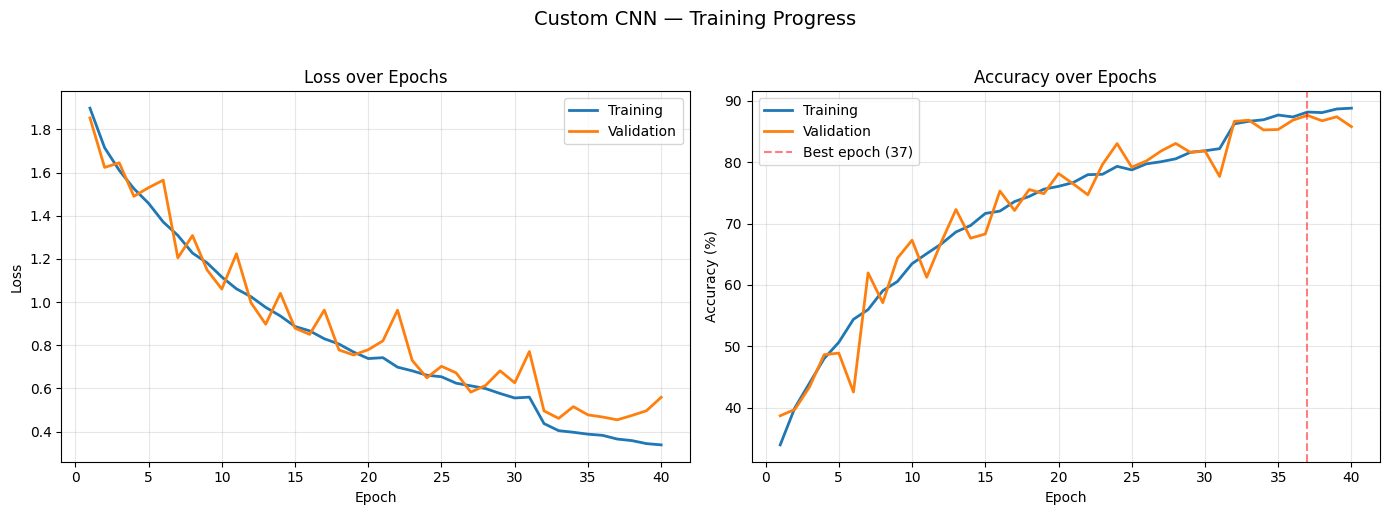

Best validation accuracy:  87.65% (epoch 37)
Final training accuracy:   88.83%
Final validation accuracy: 85.81%
Generalization gap:        3.02%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# --- Loss plot ---
ax1.plot(epochs_range, history['train_loss'], label='Training', linewidth=2)
ax1.plot(epochs_range, history['val_loss'], label='Validation', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy plot ---
ax2.plot(epochs_range, history['train_acc'], label='Training', linewidth=2)
ax2.plot(epochs_range, history['val_acc'], label='Validation', linewidth=2)
best_epoch = int(np.argmax(history['val_acc'])) + 1
ax2.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
            label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Custom CNN — Training Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary metrics
print(f"Best validation accuracy:  {max(history['val_acc']):.2f}% (epoch {best_epoch})")
print(f"Final training accuracy:   {history['train_acc'][-1]:.2f}%")
print(f"Final validation accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Generalization gap:        {history['train_acc'][-1] - history['val_acc'][-1]:.2f}%")

## 6. Custom CNN Evaluation

A single accuracy number can hide important details, especially on imbalanced datasets where a model might excel on majority classes while failing on minority ones. This section provides a thorough evaluation through three complementary views.

### Classification Report

For each class, the report shows:

- **Precision** — of all images the model predicted as this class, what fraction were correct. High precision means few false positives.
- **Recall** — of all images that actually belong to this class, what fraction the model identified. High recall means few false negatives.
- **F1-score** — the harmonic mean of precision and recall, providing a single balanced metric.
- **Support** — the number of validation samples belonging to each class.

The report also includes macro-averages (treating all classes equally) and weighted averages (weighting by support).

### Confusion Matrices

Two confusion matrices are displayed:

- **Raw counts** — shows the actual number of samples for each true/predicted class pair. Useful for understanding the absolute scale of errors.
- **Row-normalized** — each row sums to 1.0, showing the fraction of each true class predicted as each class. This makes per-class accuracy directly comparable regardless of class size.

The diagonal contains correct predictions; off-diagonal cells reveal which classes get confused with which. Patterns like "metal frequently misclassified as plastic" indicate visually similar categories where the model struggles — valuable insight for understanding model limitations and identifying potential improvements.

Overall Validation Accuracy: 87.65%

Classification Report:
              precision    recall  f1-score   support

     battery      0.929     0.849     0.887       185
  biological      0.915     0.905     0.910       201
   cardboard      0.926     0.885     0.905       383
     clothes      0.967     0.950     0.958      1053
       glass      0.907     0.823     0.863       617
       metal      0.662     0.907     0.765       194
       paper      0.874     0.884     0.879       336
     plastic      0.840     0.778     0.808       405
       shoes      0.793     0.862     0.826       392
       trash      0.702     0.818     0.756       187

    accuracy                          0.877      3953
   macro avg      0.851     0.866     0.856      3953
weighted avg      0.884     0.877     0.878      3953



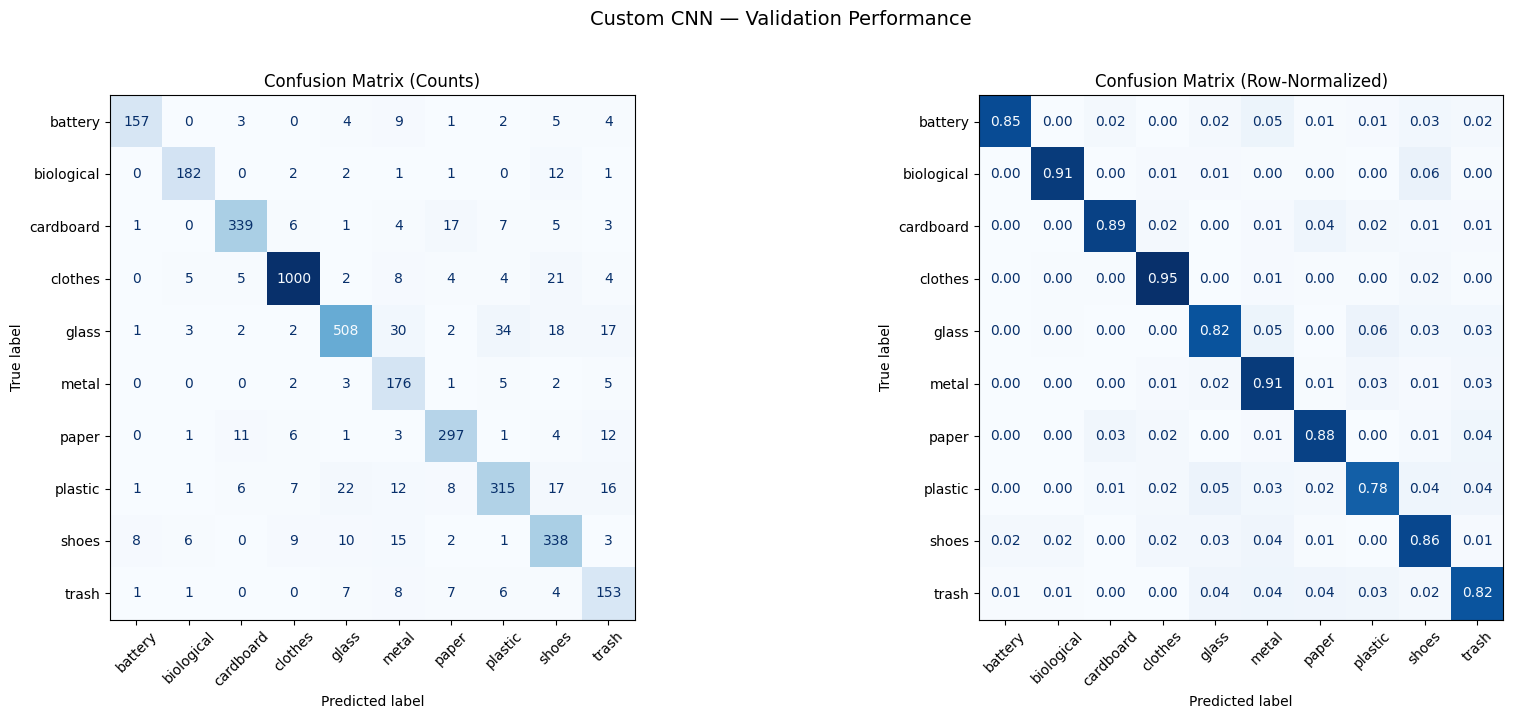


Results stored for later comparison.


In [7]:
# Run inference on the entire validation set
custom_cnn.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = custom_cnn(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ============================================================
# Overall accuracy
# ============================================================
overall_acc = 100.0 * (all_preds == all_labels).mean()
print(f"Overall Validation Accuracy: {overall_acc:.2f}%\n")

# ============================================================
# Per-class classification report
# ============================================================
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

# ============================================================
# Confusion matrices (raw + normalized)
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp1.plot(ax=ax1, xticks_rotation=45, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix (Counts)')

# Row-normalized
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=classes)
disp2.plot(ax=ax2, xticks_rotation=45, cmap='Blues', colorbar=False, values_format='.2f')
ax2.set_title('Confusion Matrix (Row-Normalized)')

plt.suptitle('Custom CNN — Validation Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Store custom CNN results for later comparison with the pretrained model
custom_results = {
    'accuracy': overall_acc,
    'preds': all_preds.copy(),
    'labels': all_labels.copy(),
    'confusion_matrix': cm,
}
print(f"\nResults stored for later comparison.")

## 7. Transfer Learning with Pretrained ResNet50

Transfer learning leverages a network that has already learned rich visual representations from a large dataset and adapts it to a new task. Instead of training a model from random initialization on the (relatively small) garbage dataset, we start from weights that have already been optimized on ImageNet — 1.2 million images spanning 1,000 object categories.

### Why ResNet50

**ResNet50** is a 50-layer residual network introduced by He et al. (2015). It uses skip connections to enable training of very deep networks without the vanishing gradient problem that plagued earlier architectures. ResNet50 strikes a strong balance between accuracy and computational cost — deeper than ResNet18/34 (more representational capacity) but lighter than ResNet101/152 (faster training and inference). It is one of the most widely used backbones in computer vision and is immediately recognizable to any ML practitioner.

The IMAGENET1K_V2 weights are loaded, corresponding to torchvision's improved training recipe (~80.86% ImageNet top-1 accuracy versus 76.13% for V1).

### Two-Stage Training Strategy

A two-stage approach is used:

1. **Feature extraction (warm-up)** — All backbone layers are frozen. Only the new classification head is trained for a few epochs. This allows the randomly initialized head to learn from the pretrained features without disrupting them with large gradient updates.

2. **Fine-tuning** — Backbone layers are unfrozen and the entire network is trained with a much smaller learning rate. This allows the pretrained representations to gently adapt to the specifics of the garbage classification task.

This staged approach typically yields better final accuracy than directly fine-tuning the whole network from the start, and is the standard practice in modern transfer learning.

### Architecture Modification

ResNet50's final fully-connected layer outputs 1,000 logits (one per ImageNet class). It is replaced with a new linear layer outputting 10 logits — one per garbage category. The new layer's weights are randomly initialized; everything else inherits ImageNet-trained values.

This cell handles loading the pretrained model and preparing it for stage 1 (feature extraction). The actual training happens in the next cell.

In [8]:
from torchvision.models import resnet50, ResNet50_Weights

# ============================================================
# Load ResNet50 pretrained on ImageNet
# Using V2 weights (improved training recipe: ~80.86% ImageNet top-1)
# ============================================================
weights = ResNet50_Weights.IMAGENET1K_V2
pretrained_model = resnet50(weights=weights)

# ============================================================
# Stage 1 setup: Freeze the backbone
# All pretrained parameters are frozen so that only the new
# classifier head is trained during the warm-up phase.
# ============================================================
for param in pretrained_model.parameters():
    param.requires_grad = False

# ============================================================
# Replace the final classification layer
# ResNet50's `fc` layer maps 2048 features to 1000 ImageNet classes.
# We replace it with a new layer mapping 2048 features to our 10 classes.
# New layer parameters have requires_grad=True by default.
# ============================================================
num_features = pretrained_model.fc.in_features
pretrained_model.fc = nn.Linear(num_features, num_classes)

# Move the model to the GPU
pretrained_model = pretrained_model.to(device)

# ============================================================
# Parameter count summary
# ============================================================
total_params = sum(p.numel() for p in pretrained_model.parameters())
trainable_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (new classifier head)")
print(f"Frozen parameters:    {frozen_params:,} (ImageNet backbone)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]


Total parameters:     23,528,522
Trainable parameters: 20,490 (new classifier head)
Frozen parameters:    23,508,032 (ImageNet backbone)


## 7.1. Optional: Load Pretrained Weights (Skip Training)

As with the custom CNN, you can skip the full two-stage training and load the already-trained ResNet50 weights here. The weights file contains the fully fine-tuned model after both stages of training.

If you want to train from scratch instead, skip this cell and run the next training cell.

In [ ]:
# Path to the folder containing the saved weights and history files.
# Update this path to match your environment.
WEIGHTS_DIR = "/content/drive/MyDrive/CNNProject"

# Before loading, unfreeze all parameters so the state dict matches
# the post-fine-tuning state in which it was saved.
for param in pretrained_model.parameters():
    param.requires_grad = True

# Load ResNet50 weights
pretrained_model.load_state_dict(torch.load(f"{WEIGHTS_DIR}/resnet50_best.pth"))
pretrained_model.eval()

# Load training history
with open(f"{WEIGHTS_DIR}/resnet50_history.json") as f:
    resnet_history = json.load(f)

# Restore stage 1 epoch count (used by the training curves visualization)
STAGE1_EPOCHS = 5

print(f"ResNet50 weights loaded from {WEIGHTS_DIR}/resnet50_best.pth")
print(f"Best validation accuracy from saved history: {max(resnet_history['val_acc']):.2f}%")

## 8. Training the Pretrained Model — Two-Stage Approach

This cell trains the pretrained ResNet50 in two distinct stages, each with its own learning rate and optimizer configuration.

### Stage 1: Feature Extraction (Warm-Up)

- **Frozen backbone, only classifier head trains**
- Learning rate: $10^{-3}$
- Duration: 5 epochs

When fine-tuning a pretrained network, the new classifier head starts with random weights. If both the head and backbone were trained simultaneously from the start, the large initial gradients flowing from the random head into the backbone would corrupt the carefully learned ImageNet features. The warm-up phase prevents this by training only the head first, letting it learn a reasonable mapping from frozen features to garbage classes before any backbone updates occur.

This stage is very fast because backward passes only compute gradients for the new linear layer (a few thousand parameters versus 23+ million in the full network).

### Stage 2: End-to-End Fine-Tuning

- **All layers unfrozen, full network trains**
- Learning rate: $10^{-4}$ (10× smaller than stage 1)
- Duration: 15 epochs
- Learning rate scheduler: `ReduceLROnPlateau`

After warm-up, all backbone layers are unfrozen and training continues with a much smaller learning rate. The reduced learning rate is essential — large updates would still distort the pretrained features. Instead, we apply gentle, gradient-based refinements that adapt the backbone to the nuances of garbage imagery (different lighting, textures, and object types than ImageNet) while preserving its general visual knowledge.

The `ReduceLROnPlateau` scheduler further decreases the learning rate when validation loss stops improving, enabling the model to converge to a tighter optimum.

### Shared Components

The same class-weighted cross-entropy loss used for the custom CNN is reused here, ensuring both models train against identical class imbalance correction. Best-model selection (by validation accuracy) and history logging follow the same pattern as the custom CNN training, allowing direct comparison between the two approaches.

In [9]:
# ============================================================
# Loss function (same class weights as the custom CNN)
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ============================================================
# History and best-model tracking (shared across both stages)
# ============================================================
resnet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_resnet_weights = copy.deepcopy(pretrained_model.state_dict())

# ============================================================
# STAGE 1: Feature Extraction (Warm-Up)
# Train only the new classifier head with the backbone frozen.
# ============================================================
print("=" * 80)
print("STAGE 1: Feature extraction — training only the new classifier head")
print("=" * 80)

STAGE1_EPOCHS = 5
STAGE1_LR = 1e-3

# Optimizer over only the trainable parameters (the new FC layer)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=STAGE1_LR,
    weight_decay=1e-4,
)

print(f"\n{'Epoch':>5} | {'TrainLoss':>10} {'TrainAcc':>9} | {'ValLoss':>10} {'ValAcc':>9} | {'Time':>6}")
print("-" * 70)

for epoch in range(STAGE1_EPOCHS):
    start_time = time.time()

    # --- Train ---
    pretrained_model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = pretrained_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)
    train_loss = running_loss / running_total
    train_acc = 100.0 * running_correct / running_total

    # --- Validate ---
    pretrained_model.eval()
    running_loss, running_correct, running_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = pretrained_model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)
    val_loss = running_loss / running_total
    val_acc = 100.0 * running_correct / running_total

    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_acc'].append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_resnet_weights = copy.deepcopy(pretrained_model.state_dict())

    epoch_time = time.time() - start_time
    marker = "  *" if is_best else ""
    print(f"{epoch+1:>5} | {train_loss:>10.4f} {train_acc:>8.2f}% | "
          f"{val_loss:>10.4f} {val_acc:>8.2f}% | {epoch_time:>5.1f}s{marker}")

# ============================================================
# STAGE 2: End-to-End Fine-Tuning
# Unfreeze all layers and train with a lower learning rate.
# ============================================================
print("\n" + "=" * 80)
print("STAGE 2: Fine-tuning — all layers trainable, reduced learning rate")
print("=" * 80)

# Unfreeze every parameter
for param in pretrained_model.parameters():
    param.requires_grad = True

STAGE2_EPOCHS = 15
STAGE2_LR = 1e-4

# Fresh optimizer over the full network with a smaller learning rate
optimizer = optim.Adam(pretrained_model.parameters(), lr=STAGE2_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"\n{'Epoch':>5} | {'TrainLoss':>10} {'TrainAcc':>9} | {'ValLoss':>10} {'ValAcc':>9} | {'LR':>10} | {'Time':>6}")
print("-" * 80)

for epoch in range(STAGE2_EPOCHS):
    start_time = time.time()

    # --- Train ---
    pretrained_model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = pretrained_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)
    train_loss = running_loss / running_total
    train_acc = 100.0 * running_correct / running_total

    # --- Validate ---
    pretrained_model.eval()
    running_loss, running_correct, running_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = pretrained_model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)
    val_loss = running_loss / running_total
    val_acc = 100.0 * running_correct / running_total

    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_acc'].append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        best_resnet_weights = copy.deepcopy(pretrained_model.state_dict())

    epoch_time = time.time() - start_time
    marker = "  *" if is_best else ""
    print(f"{epoch+1:>5} | {train_loss:>10.4f} {train_acc:>8.2f}% | "
          f"{val_loss:>10.4f} {val_acc:>8.2f}% | {current_lr:>10.6f} | "
          f"{epoch_time:>5.1f}s{marker}")

# ============================================================
# Restore best weights and save
# ============================================================
pretrained_model.load_state_dict(best_resnet_weights)
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

torch.save(best_resnet_weights, os.path.join(SAVE_DIR, "resnet50_best.pth"))
with open(os.path.join(SAVE_DIR, "resnet50_history.json"), "w") as f:
    json.dump(resnet_history, f)
print(f"Best model saved to: {SAVE_DIR}/resnet50_best.pth")

STAGE 1: Feature extraction — training only the new classifier head

Epoch |  TrainLoss  TrainAcc |    ValLoss    ValAcc |   Time
----------------------------------------------------------------------
    1 |     0.6747    84.85% |     0.3617    91.47% |  79.8s  *
    2 |     0.3522    90.63% |     0.2755    93.22% |  79.0s  *
    3 |     0.2911    91.85% |     0.2485    93.47% |  79.5s  *
    4 |     0.2660    92.30% |     0.2391    93.45% |  78.9s
    5 |     0.2390    92.93% |     0.2264    93.98% |  77.8s  *

STAGE 2: Fine-tuning — all layers trainable, reduced learning rate

Epoch |  TrainLoss  TrainAcc |    ValLoss    ValAcc |         LR |   Time
--------------------------------------------------------------------------------
    1 |     0.1811    94.64% |     0.1477    95.50% |   0.000100 |  79.7s  *
    2 |     0.0850    97.32% |     0.1360    96.05% |   0.000100 |  80.7s  *
    3 |     0.0581    98.20% |     0.1478    96.08% |   0.000100 |  79.6s  *
    4 |     0.0493    98.36

## 9. Visualizing ResNet50 Training Progress

The training curves for the pretrained model reveal characteristics specific to transfer learning. Compared to training from scratch, the following patterns are typical:

- **High initial accuracy** — even after a single epoch, validation accuracy is far above random (10%). This reflects the value of the pretrained features: ResNet50 already knows how to extract meaningful visual representations.
- **Stage 1 rapid convergence** — during the warm-up phase, the classifier head learns quickly because it only needs to discover the right linear mapping from frozen features to garbage classes.
- **Stage 2 accuracy bump** — when the backbone unfreezes, the model often shows another jump in accuracy as the deeper layers fine-tune to dataset-specific features.
- **Smaller generalization gap** — pretrained models typically overfit less than from-scratch networks on small datasets, since the backbone's representations are already well-regularized by ImageNet's diversity.

The stage 1 epoch range is shaded on both plots to make the two-stage structure visually obvious.

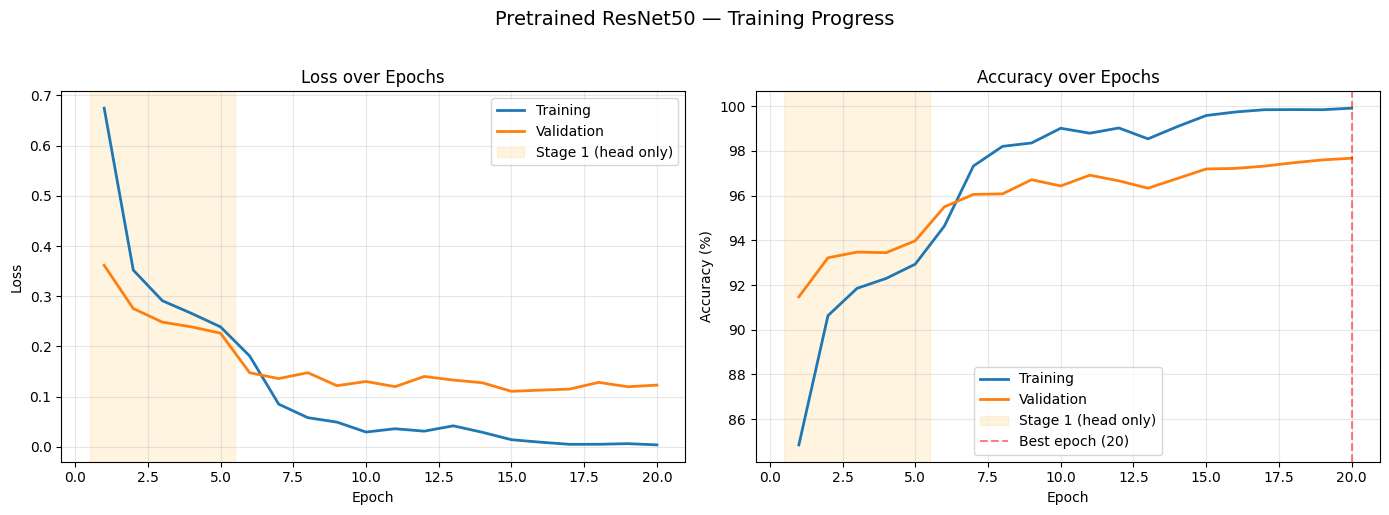

Best validation accuracy:  97.67% (epoch 20)
Final training accuracy:   99.91%
Final validation accuracy: 97.67%
Generalization gap:        2.24%


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(resnet_history['train_loss']) + 1)

# --- Loss plot ---
ax1.plot(epochs_range, resnet_history['train_loss'], label='Training', linewidth=2)
ax1.plot(epochs_range, resnet_history['val_loss'], label='Validation', linewidth=2)
ax1.axvspan(0.5, STAGE1_EPOCHS + 0.5, alpha=0.12, color='orange',
            label='Stage 1 (head only)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy plot ---
ax2.plot(epochs_range, resnet_history['train_acc'], label='Training', linewidth=2)
ax2.plot(epochs_range, resnet_history['val_acc'], label='Validation', linewidth=2)
ax2.axvspan(0.5, STAGE1_EPOCHS + 0.5, alpha=0.12, color='orange',
            label='Stage 1 (head only)')
best_epoch = int(np.argmax(resnet_history['val_acc'])) + 1
ax2.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
            label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Pretrained ResNet50 — Training Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary metrics
print(f"Best validation accuracy:  {max(resnet_history['val_acc']):.2f}% (epoch {best_epoch})")
print(f"Final training accuracy:   {resnet_history['train_acc'][-1]:.2f}%")
print(f"Final validation accuracy: {resnet_history['val_acc'][-1]:.2f}%")
print(f"Generalization gap:        {resnet_history['train_acc'][-1] - resnet_history['val_acc'][-1]:.2f}%")

## 10. Pretrained ResNet50 Evaluation

The pretrained model is evaluated using the same metrics as the custom CNN — classification report and confusion matrices — to enable a direct, fair comparison. Using identical evaluation methodology is essential: any difference in performance between the two models must come from the models themselves, not from differences in how they are measured.

Particular attention should be paid to:

- **Per-class precision and recall** — does transfer learning improve classes uniformly, or are some categories disproportionately helped?
- **Confusion matrix off-diagonal patterns** — does the pretrained model resolve the same confusions the custom CNN struggled with (e.g., visually similar materials like glass and plastic)?
- **Macro vs. weighted F1** — significant gaps between these averages indicate uneven performance across classes.

Overall Validation Accuracy: 97.67%

Classification Report:
              precision    recall  f1-score   support

     battery      0.979     0.989     0.984       185
  biological      0.995     0.975     0.985       201
   cardboard      0.982     0.987     0.984       383
     clothes      0.996     0.988     0.992      1053
       glass      0.981     0.979     0.980       617
       metal      0.911     0.954     0.932       194
       paper      0.976     0.967     0.972       336
     plastic      0.965     0.951     0.958       405
       shoes      0.963     0.985     0.974       392
       trash      0.952     0.957     0.955       187

    accuracy                          0.977      3953
   macro avg      0.970     0.973     0.971      3953
weighted avg      0.977     0.977     0.977      3953



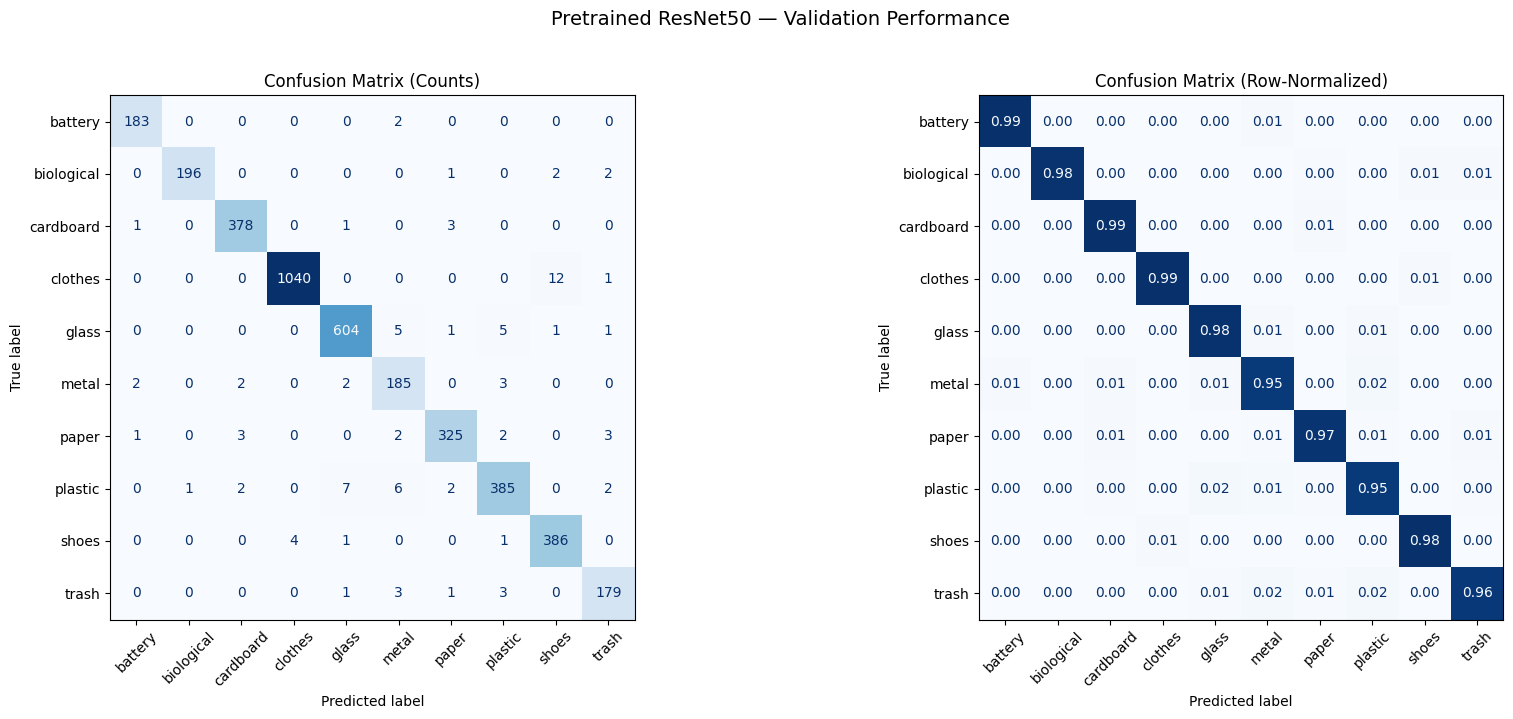


Results stored for comparison with the custom CNN.


In [11]:
# Run inference on the entire validation set
pretrained_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = pretrained_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ============================================================
# Overall accuracy
# ============================================================
overall_acc = 100.0 * (all_preds == all_labels).mean()
print(f"Overall Validation Accuracy: {overall_acc:.2f}%\n")

# ============================================================
# Per-class classification report
# ============================================================
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

# ============================================================
# Confusion matrices (raw + normalized)
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp1.plot(ax=ax1, xticks_rotation=45, cmap='Blues', colorbar=False)
ax1.set_title('Confusion Matrix (Counts)')

# Row-normalized
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=classes)
disp2.plot(ax=ax2, xticks_rotation=45, cmap='Blues', colorbar=False, values_format='.2f')
ax2.set_title('Confusion Matrix (Row-Normalized)')

plt.suptitle('Pretrained ResNet50 — Validation Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Store ResNet50 results for the side-by-side comparison
resnet_results = {
    'accuracy': overall_acc,
    'preds': all_preds.copy(),
    'labels': all_labels.copy(),
    'confusion_matrix': cm,
}
print(f"\nResults stored for comparison with the custom CNN.")

## 11. Model Comparison: Custom CNN vs. Pretrained ResNet50

This section directly compares the two approaches across multiple dimensions:

1. **Overall validation accuracy** — the headline number for each model.
2. **Per-class accuracy bar chart** — exposes where each model excels or struggles. Two models with similar overall accuracy can have very different per-class profiles.
3. **Side-by-side normalized confusion matrices** — reveals whether the same classes are confused with each other in both models, or whether the failure modes differ.

### Why This Comparison Matters

In real-world machine learning work, model selection is rarely about chasing the highest accuracy in isolation. Engineering decisions involve trade-offs:

- **Custom CNN**: ~3.9M parameters, trained entirely from scratch, fully understood architecture. Faster inference, easier to deploy on resource-constrained devices, no external dependencies on pretrained weights.
- **Pretrained ResNet50**: ~23.5M parameters, leverages 1.2M ImageNet images of prior training. Higher expected accuracy, but larger memory footprint and slower inference.

This comparison makes the trade-offs concrete, showing exactly what the additional capacity and prior knowledge of the pretrained model buy in terms of accuracy gain.

MODEL COMPARISON SUMMARY
Model                           Validation Accuracy
----------------------------------------------------------------------
Custom CNN (from scratch)                    87.65%
Pretrained ResNet50                          97.67%
----------------------------------------------------------------------
Difference (ResNet50 - Custom)              +10.02%


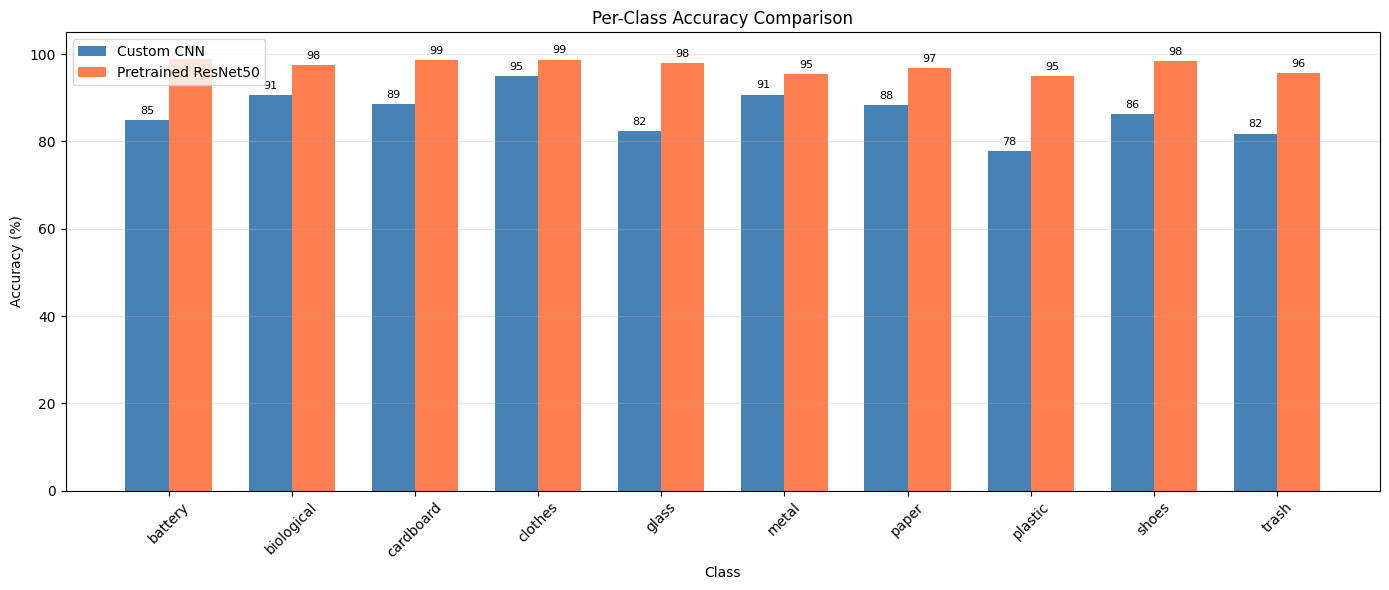

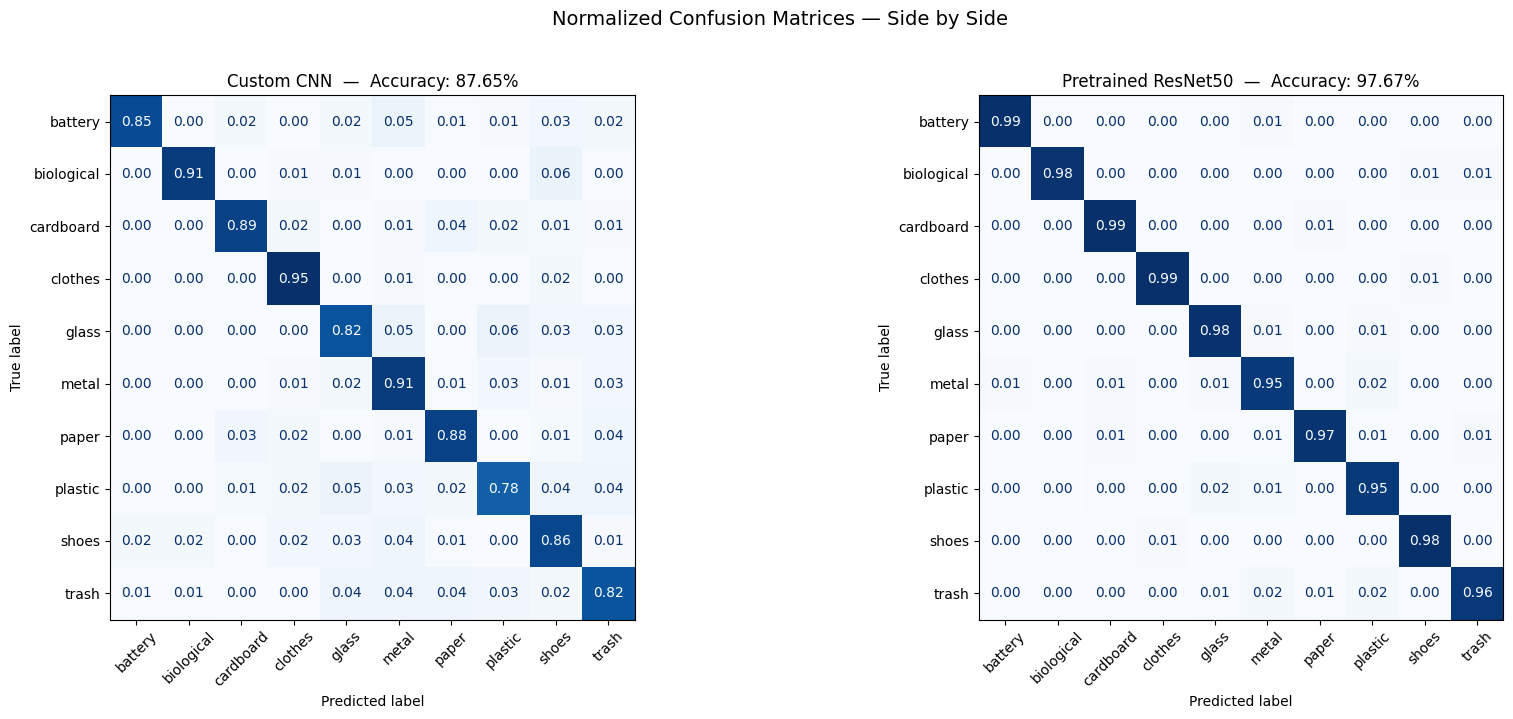


Per-class accuracy details:
Class          Custom CNN     ResNet50   Change     Winner
------------------------------------------------------------
battery             84.9%        98.9%   +14.1%   ResNet50
biological          90.5%        97.5%    +7.0%   ResNet50
cardboard           88.5%        98.7%   +10.2%   ResNet50
clothes             95.0%        98.8%    +3.8%   ResNet50
glass               82.3%        97.9%   +15.6%   ResNet50
metal               90.7%        95.4%    +4.6%   ResNet50
paper               88.4%        96.7%    +8.3%   ResNet50
plastic             77.8%        95.1%   +17.3%   ResNet50
shoes               86.2%        98.5%   +12.2%   ResNet50
trash               81.8%        95.7%   +13.9%   ResNet50


In [12]:
# ============================================================
# Headline accuracy comparison
# ============================================================
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Model':<30} {'Validation Accuracy':>20}")
print("-" * 70)
print(f"{'Custom CNN (from scratch)':<30} {custom_results['accuracy']:>19.2f}%")
print(f"{'Pretrained ResNet50':<30} {resnet_results['accuracy']:>19.2f}%")
print("-" * 70)
diff = resnet_results['accuracy'] - custom_results['accuracy']
print(f"{'Difference (ResNet50 - Custom)':<30} {diff:>+19.2f}%")
print("=" * 70)

# ============================================================
# Per-class accuracy (computed from confusion matrices)
# ============================================================
custom_per_class = (
    np.diag(custom_results['confusion_matrix'])
    / custom_results['confusion_matrix'].sum(axis=1) * 100
)
resnet_per_class = (
    np.diag(resnet_results['confusion_matrix'])
    / resnet_results['confusion_matrix'].sum(axis=1) * 100
)

# ============================================================
# Per-class accuracy bar chart
# ============================================================
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, custom_per_class, width,
               label='Custom CNN', color='steelblue')
bars2 = ax.bar(x + width/2, resnet_per_class, width,
               label='Pretrained ResNet50', color='coral')

ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 105)

# Value labels on top of each bar
for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.0f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Side-by-side normalized confusion matrices
# ============================================================
custom_cm_norm = (
    custom_results['confusion_matrix'].astype('float')
    / custom_results['confusion_matrix'].sum(axis=1, keepdims=True)
)
resnet_cm_norm = (
    resnet_results['confusion_matrix'].astype('float')
    / resnet_results['confusion_matrix'].sum(axis=1, keepdims=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

disp1 = ConfusionMatrixDisplay(confusion_matrix=custom_cm_norm, display_labels=classes)
disp1.plot(ax=ax1, xticks_rotation=45, cmap='Blues', colorbar=False, values_format='.2f')
ax1.set_title(f'Custom CNN  —  Accuracy: {custom_results["accuracy"]:.2f}%')

disp2 = ConfusionMatrixDisplay(confusion_matrix=resnet_cm_norm, display_labels=classes)
disp2.plot(ax=ax2, xticks_rotation=45, cmap='Blues', colorbar=False, values_format='.2f')
ax2.set_title(f'Pretrained ResNet50  —  Accuracy: {resnet_results["accuracy"]:.2f}%')

plt.suptitle('Normalized Confusion Matrices — Side by Side', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Detailed per-class breakdown
# ============================================================
print("\nPer-class accuracy details:")
print(f"{'Class':<12} {'Custom CNN':>12} {'ResNet50':>12} {'Change':>8} {'Winner':>10}")
print("-" * 60)
for i, cls in enumerate(classes):
    delta = resnet_per_class[i] - custom_per_class[i]
    if abs(delta) < 0.5:
        winner = "Tie"
    elif delta > 0:
        winner = "ResNet50"
    else:
        winner = "Custom"
    print(f"{cls:<12} {custom_per_class[i]:>11.1f}% {resnet_per_class[i]:>11.1f}% "
          f"{delta:>+7.1f}% {winner:>10}")

## 12. Sample Predictions Visualization

Numbers and matrices tell one story; seeing actual predictions on real images tells another. This final visualization samples random validation images and shows what each model predicted, along with the model's confidence (top softmax probability).

For each image:
- **Green border** indicates a correct prediction
- **Red border** indicates an incorrect prediction
- The custom CNN's prediction is shown on the left, ResNet50's on the right
- Confidence scores reveal whether the model was sure or uncertain about its choice

This view is particularly useful for understanding qualitative differences between the models: cases where one is confident and right while the other is hesitant, or cases where both agree, or rare cases where both fail in different ways.

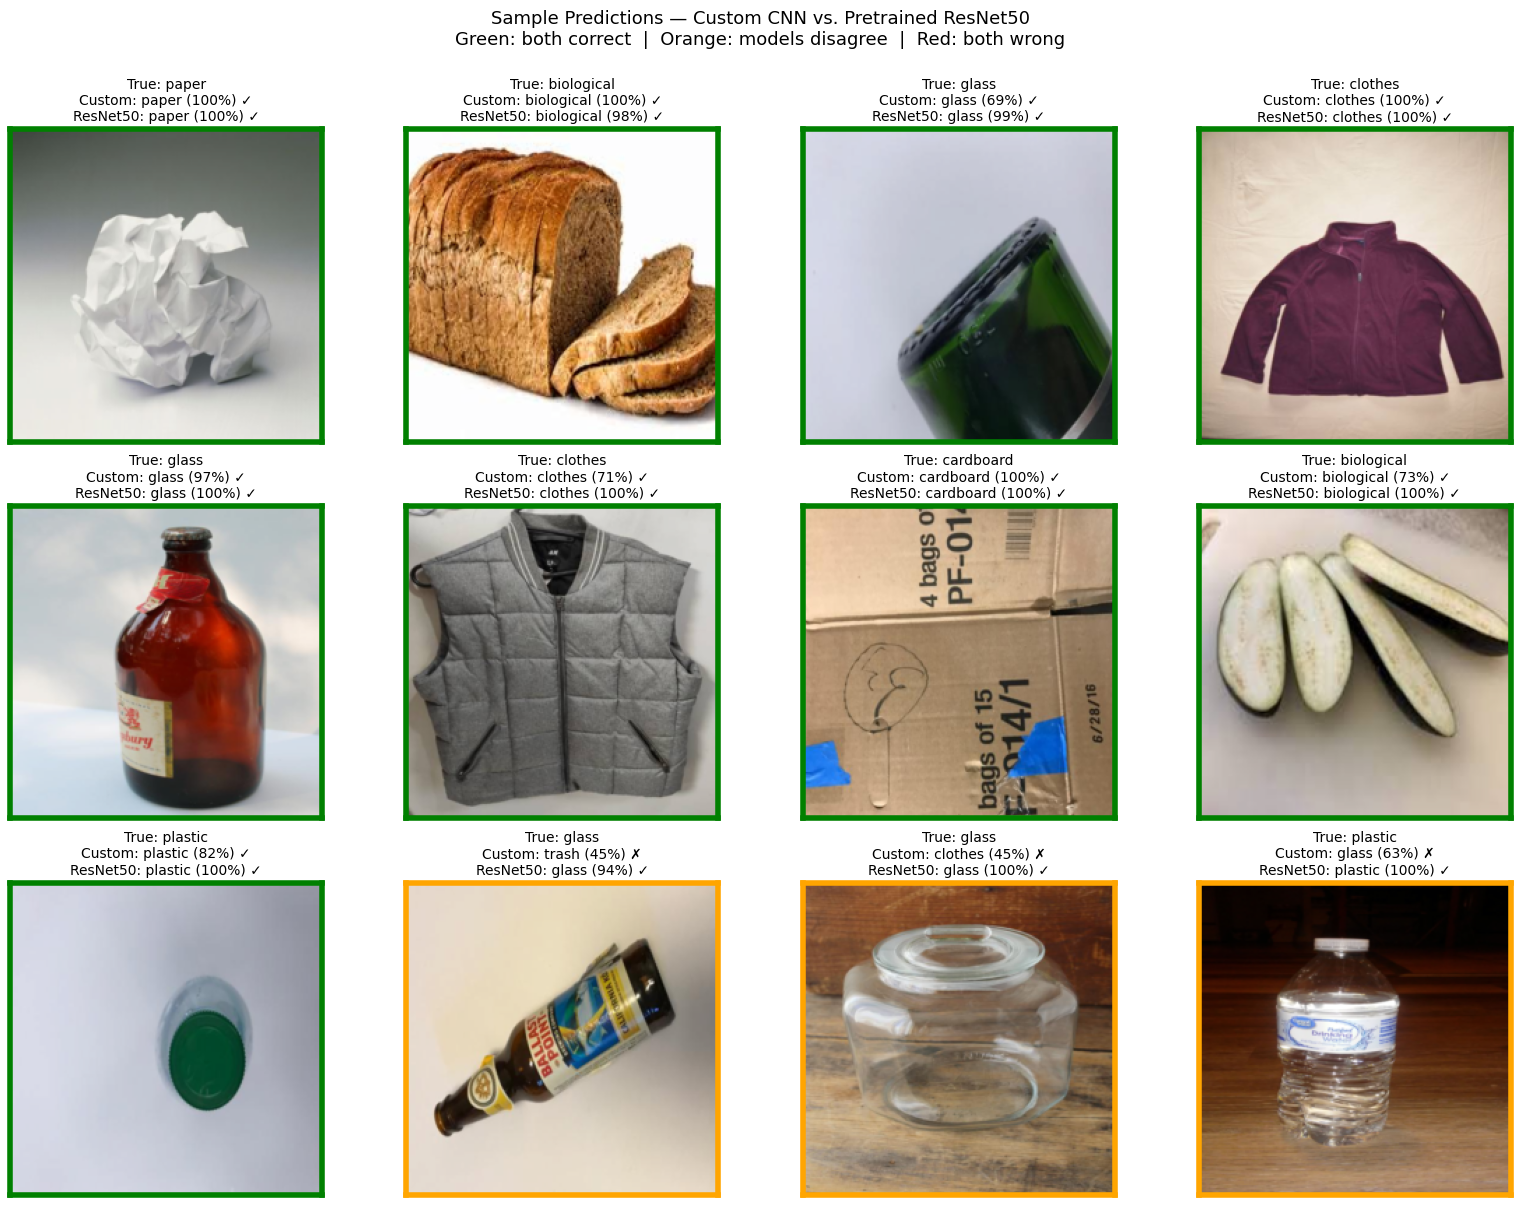

In [15]:
# ============================================================
# Sample predictions from both models side by side
# ============================================================
# Set both models to eval mode
custom_cnn.eval()
pretrained_model.eval()

# ImageNet normalization stats — needed to denormalize images for display
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def denormalize(img_tensor):
    """Convert a normalized tensor back to a displayable image."""
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)  # CHW -> HWC
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# Pick random sample indices from the validation set
NUM_SAMPLES = 12
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(val_dataset), size=NUM_SAMPLES, replace=False)

# Gather images, labels, and predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

with torch.no_grad():
    for plot_idx, sample_idx in enumerate(sample_indices):
        image, true_label = val_dataset[int(sample_idx)]
        image_batch = image.unsqueeze(0).to(device)

        # Custom CNN prediction
        custom_logits = custom_cnn(image_batch)
        custom_probs = F.softmax(custom_logits, dim=1)
        custom_conf, custom_pred = torch.max(custom_probs, 1)

        # ResNet50 prediction
        resnet_logits = pretrained_model(image_batch)
        resnet_probs = F.softmax(resnet_logits, dim=1)
        resnet_conf, resnet_pred = torch.max(resnet_probs, 1)

        custom_pred_idx = custom_pred.item()
        resnet_pred_idx = resnet_pred.item()

        custom_correct = custom_pred_idx == true_label
        resnet_correct = resnet_pred_idx == true_label

        # Choose border color: green if BOTH correct, red if BOTH wrong,
        # orange if they disagree
        if custom_correct and resnet_correct:
            border_color = 'green'
        elif not custom_correct and not resnet_correct:
            border_color = 'red'
        else:
            border_color = 'orange'

        ax = axes[plot_idx]
        ax.imshow(denormalize(image))
        ax.set_title(
            f"True: {classes[true_label]}\n"
            f"Custom: {classes[custom_pred_idx]} "
            f"({custom_conf.item()*100:.0f}%) "
            f"{'✓' if custom_correct else '✗'}\n"
            f"ResNet50: {classes[resnet_pred_idx]} "
            f"({resnet_conf.item()*100:.0f}%) "
            f"{'✓' if resnet_correct else '✗'}",
            fontsize=10,
        )

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)

plt.suptitle(
    'Sample Predictions — Custom CNN vs. Pretrained ResNet50\n'
    'Green: both correct  |  Orange: models disagree  |  Red: both wrong',
    fontsize=13, y=1.00,
)
plt.tight_layout()
plt.show()